In [ ]:
import0import0importimport numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import warnings

In [ ]:
from google.colab import files
#uploaded = files.upload()


In [ ]:
uploadeduploadeduploadeduploadeduploadeduploadeduploadeduploadeduploadeduploadeduploadeduploadeduploadeduploadeduploadeduploadeduploadeduploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
readreadreadreadreadreadreadreadeadreadreadeadreadread_csv('train.csv', encoding='cp1251', sep=';')
test =readreadreadreadreadreadreadreadreadreadreadread_excel('test.xlsx')

/tmp/ipykernel_2631/439902088.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('train.csv', encoding='cp1251', sep=';')


Перед нами задача бинарной классификации с учителем.

В качестве метрики выбрана AUC-ROC. Она показывает способность модели разделять заемщиков на два класса (будет ли заёмщик испытывать финансовые трудности или нет). Выбор обусловлен:

*   Устойчивостью к дисбалансу классов. В кредитных задачах часто бывает значительно больше "хороших" клиентов (Target=0), чем "проблемных" (Target=1). AUC, в отличие от обычной точности (accuracy), не зависит от порога классификации и корректно работает при дисбалансе.
*   Интерпретируемостью. AUC показывает, насколько хорошо модель разделяет два класса, не требуя выбора конкретного порога принятия решения.


AUC вычисляется как площадь под ROC-кривой. ROC-кривая строится в координатах:


TPR (True Positive Rate) = чувствительность = TP / (TP + FN) – доля правильно предсказанных проблемных клиентов;


FPR (False Positive Rate) = 1 – специфичность = FP / (FP + TN) – доля ошибочно предсказанных проблем среди хороших клиентов.


При изменении порога классификации от 0 до 1 мы получаем набор точек (FPR, TPR), соединяя которые получаем ROC-кривую. Геометрически: AUC = интеграл от TPR по d(FPR) от 0 до 1.


Лучшее значение — 1.0, худшее — 0.5 (случайное гадание).



#2 Предобработка данных

In [ ]:
train.isnull().sum()

,0
Unnamed: 0,16184
Age,16184
FamilySize,18856
PastDueLess_60,16184
PastDue60_90,16184
PastDue90_More,16184
DebtRatio,16184
MonthlyIncome,35934
TotalBalanceDivideCreditLimits,16184
OpenLoans,16184


In [ ]:
test.isnull().sum()

,0
Age,0
FamilySize,490
PastDueLess_60,0
PastDue60_90,0
PastDue90_More,0
DebtRatio,0
MonthlyIncome,3965
TotalBalanceDivideCreditLimits,0
OpenLoans,0
RealEstateLoans,0


In [ ]:
train1 = train.dropna().reset_index(drop=True)

In [ ]:
# Типы данных
print(train.dtypes)

Unnamed: 0                        float64
Age                               float64
FamilySize                        float64
PastDueLess_60                    float64
PastDue60_90                      float64
PastDue90_More                    float64
DebtRatio                          object
MonthlyIncome                     float64
TotalBalanceDivideCreditLimits     object
OpenLoans                         float64
RealEstateLoans                   float64
Target                            float64
dtype: object


In [ ]:
# Оставляем только числа, остальное в NaN
train1['DebtRatio'] = pd.to_numeric(train1['DebtRatio'].astype(str).str.replace(',', '.'), errors='coerce')
train1['TotalBalanceDivideCreditLimits'] = pd.to_numeric(train1['TotalBalanceDivideCreditLimits'].astype(str).str.replace(',', '.'), errors='coerce')

test['DebtRatio'] = pd.to_numeric(test['DebtRatio'].astype(str).str.replace(',', '.'), errors='coerce')
test['TotalBalanceDivideCreditLimits'] = pd.to_numeric(test['TotalBalanceDivideCreditLimits'].astype(str).str.replace(',', '.'), errors='coerce')

train1 = train1.dropna().reset_index(drop=True)

test['MonthlyIncome'] = test['MonthlyIncome'].fillna(train1['MonthlyIncome'].median())
test['FamilySize'] = test['FamilySize'].fillna(train1['FamilySize'].median())
print(train1.dtypes)

Unnamed: 0                        float64
Age                               float64
FamilySize                        float64
PastDueLess_60                    float64
PastDue60_90                      float64
PastDue90_More                    float64
DebtRatio                         float64
MonthlyIncome                     float64
TotalBalanceDivideCreditLimits    float64
OpenLoans                         float64
RealEstateLoans                   float64
Target                            float64
dtype: object


# 3 Графики

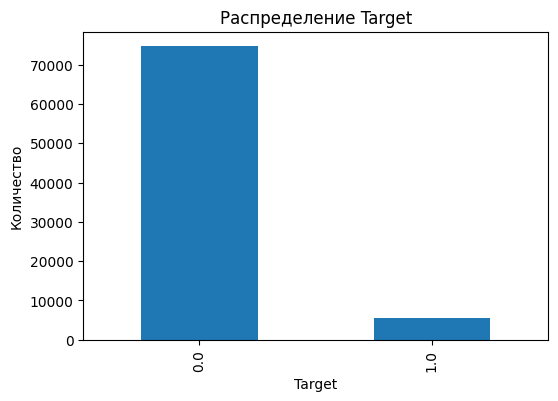

Target
0.0    0.930599
1.0    0.069401
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Баланс классов
plt.figure(figsize=(6,4))
train1['Target'].value_counts().plot(kind='bar')
plt.title('Распределение Target')
plt.xlabel('Target')
plt.ylabel('Количество')
plt.show()
print(train1['Target'].value_counts(normalize=True))

Мы видим, что классы распределены как 93.06% к 6.94%. Это эмпирически подтверждает
обоснованность выбора метрики AUC-ROC, сделанного в пункте 1, так как обычная точность
(Accuracy) в таких условиях была бы неинформативной.

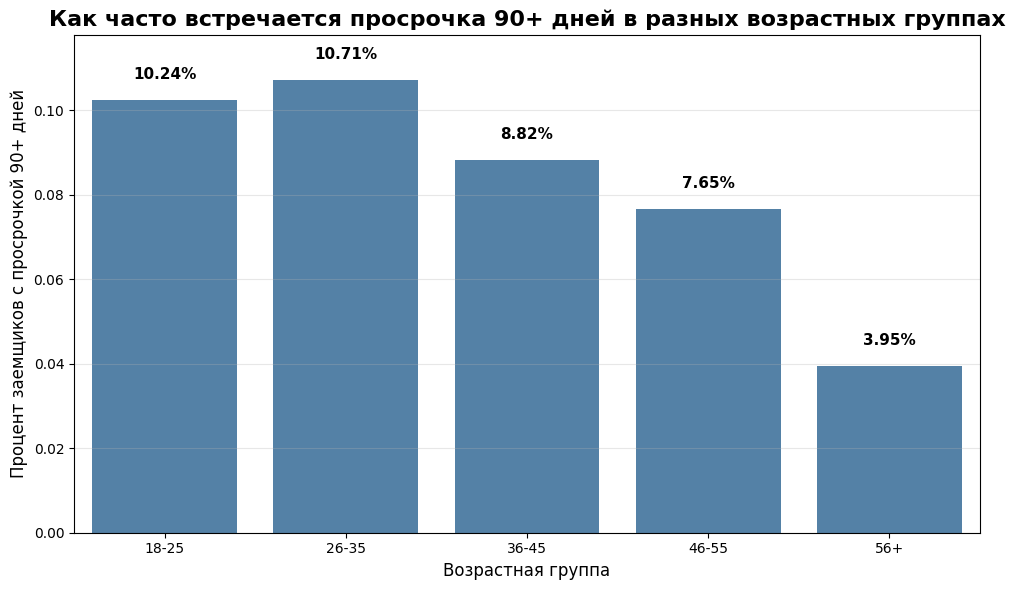

In [ ]:
# Создаем возрастные группы и считаем риск
train1['AgeGroup'] = pd.cut(train1['Age'], bins=[0,25,35,45,55,100], labels=['18-25', '26-35', '36-45', '46-55', '56+'])
age_risk = train1.groupby('AgeGroup', observed=True)['Target'].mean().reset_index()

# Строим график
plt.figure(figsize=(10,6))
bars = sns.barplot(data=age_risk, x='AgeGroup', y='Target', color='steelblue')
plt.title('Как часто встречается просрочка 90+ дней в разных возрастных группах', fontsize=16, fontweight='bold')
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Процент заемщиков с просрочкой 90+ дней', fontsize=12)
plt.ylim(0, age_risk['Target'].max() * 1.1)

# Добавляем значения на столбцы
for i, bar in enumerate(bars.patches):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
              f'{age_risk["Target"].iloc[i]:.2%}', ha='center', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Молодые заемщики в возрасте 18-35 лет показывают наибольшую долю просрочек (около 10.5%), тогда как среди заемщиков старше 55 лет этот показатель снижается до 3.95%. Это говорит о том, что возраст является значимым фактором: чем старше заемщик, тем реже у него возникают финансовые трудности.

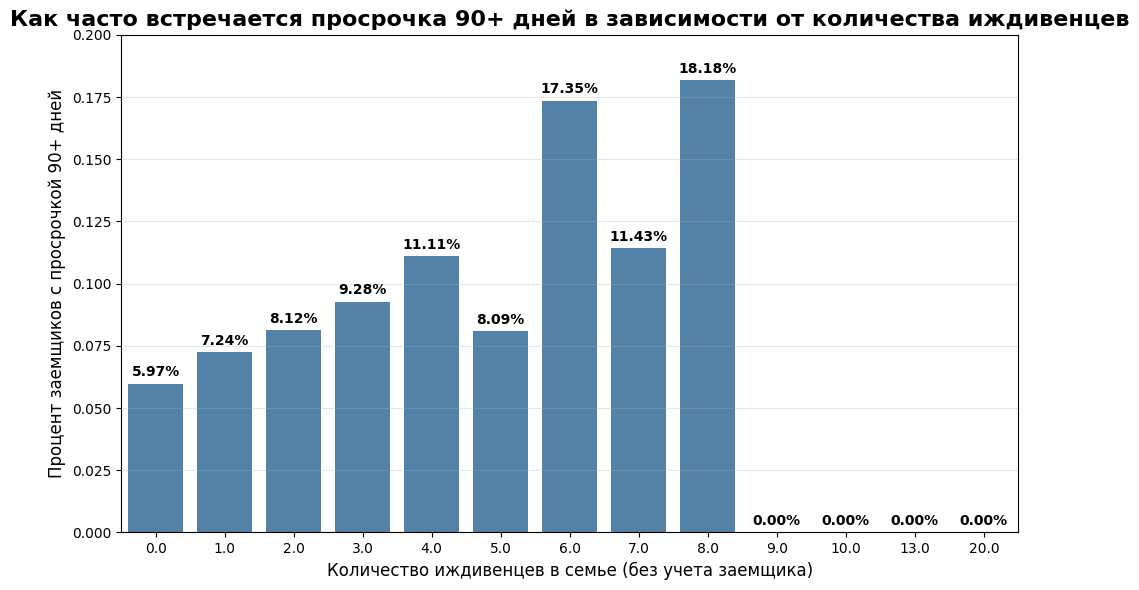

In [ ]:
# Создаем группировку по размеру семьи
family_risk = train1.groupby('FamilySize')['Target'].mean().reset_index()

plt.figure(figsize=(10,6))
bars = sns.barplot(data=family_risk, x='FamilySize', y='Target', color='steelblue')
plt.title('Как часто встречается просрочка 90+ дней в зависимости от количества иждивенцев', fontsize=16, fontweight='bold')
plt.xlabel('Количество иждивенцев в семье (без учета заемщика)', fontsize=12)
plt.ylabel('Процент заемщиков с просрочкой 90+ дней', fontsize=12)
plt.ylim(0, family_risk['Target'].max() * 1.1)

# Добавляем значения на столбцы
for i, bar in enumerate(bars.patches):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
              f'{family_risk["Target"].iloc[i]:.2%}', ha='center', fontsize=10, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

99-й перцентиль дохода: 25000
Максимальный доход: 3008750


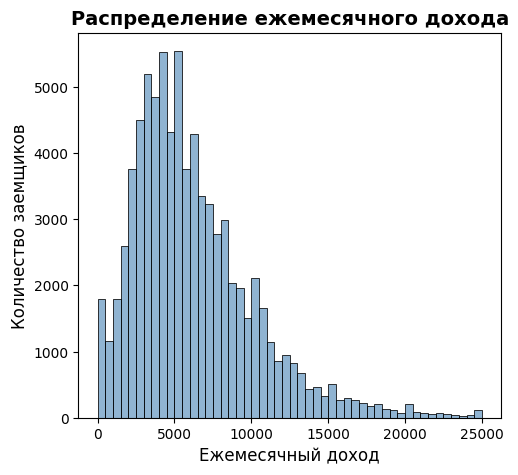

In [ ]:
plt.figure(figsize=(12,5))

upper_limit = train1['MonthlyIncome'].quantile(0.99)
income_filtered = train1[train1['MonthlyIncome'] <= upper_limit]

plt.subplot(1,2,1)
sns.histplot(data=income_filtered, x='MonthlyIncome', bins=50, color='steelblue', alpha=0.6)
plt.title('Распределение ежемесячного дохода', fontsize=14, fontweight='bold')
plt.xlabel('Ежемесячный доход', fontsize=12)
plt.ylabel('Количество заемщиков', fontsize=12)

print(f"99-й перцентиль дохода: {upper_limit:.0f}")
print(f"Максимальный доход: {train1['MonthlyIncome'].max():.0f}")

Вывод по графику распределения дохода:

Распределение ежемесячного дохода заемщиков имеет скошенный вправо вид (длинный правый хвост). Большинство заемщиков (99%) имеют доход до 25 000, при этом наблюдаются единичные выбросы с экстремально высоким доходом (до 3 млн). Это означает, что типичный заемщик банка — это человек со средним или ниже среднего доходом, а люди с очень высокими доходами встречаются редко.

Для дальнейшего анализа и построения моделей необходимо учитывать эту особенность: признаки с таким распределением лучше масштабировать или применять логарифмическое преобразование, чтобы уменьшить влияние выбросов.

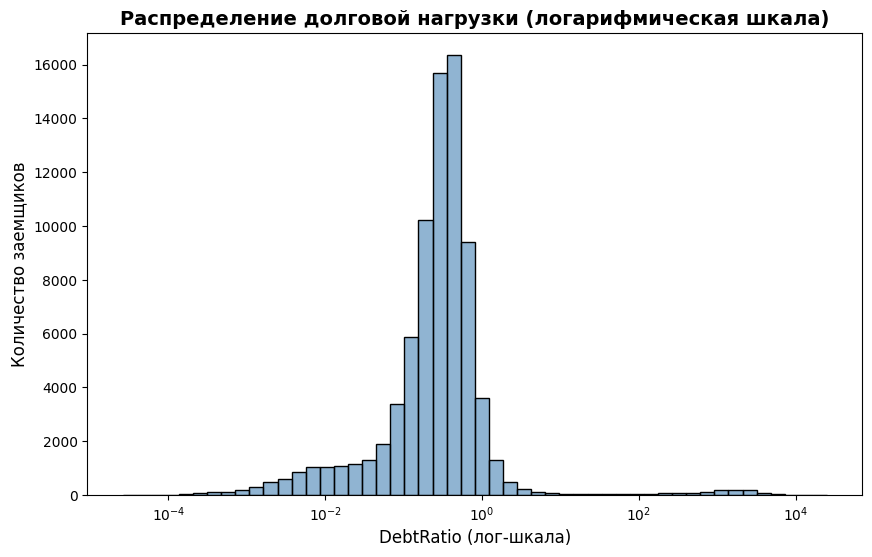

Медиана DebtRatio: 0.30
Среднее DebtRatio: 25.88
Процент заемщиков с DebtRatio > 100: 1.41%


In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=train1, x='DebtRatio', bins=50, color='steelblue', alpha=0.6, log_scale=True)
plt.title('Распределение долговой нагрузки (логарифмическая шкала)', fontsize=14, fontweight='bold')
plt.xlabel('DebtRatio (лог-шкала)', fontsize=12)
plt.ylabel('Количество заемщиков', fontsize=12)
plt.show()

print(f"Медиана DebtRatio: {train1['DebtRatio'].median():.2f}")
print(f"Среднее DebtRatio: {train1['DebtRatio'].mean():.2f}")
print(f"Процент заемщиков с DebtRatio > 100: {(train1['DebtRatio'] > 100).mean()*100:.2f}%")

Распределение DebtRatio сильно скошено вправо: медиана составляет всего 0.30%, в то время как среднее значение — 25.88%. Это означает, что большинство заемщиков имеют низкую долговую нагрузку (менее 1% от дохода), но небольшое количество заемщиков (около 1.41%) имеют экстремально высокие значения DebtRatio (более 100% от дохода), которые сильно искажают среднее. Такие выбросы могут быть как ошибками в данных, так и реальными случаями, когда долги превышают доход. Для построения моделей рекомендуется ограничить DebtRatio разумным порогом (например, 100-200%) или применить логарифмическое преобразование.

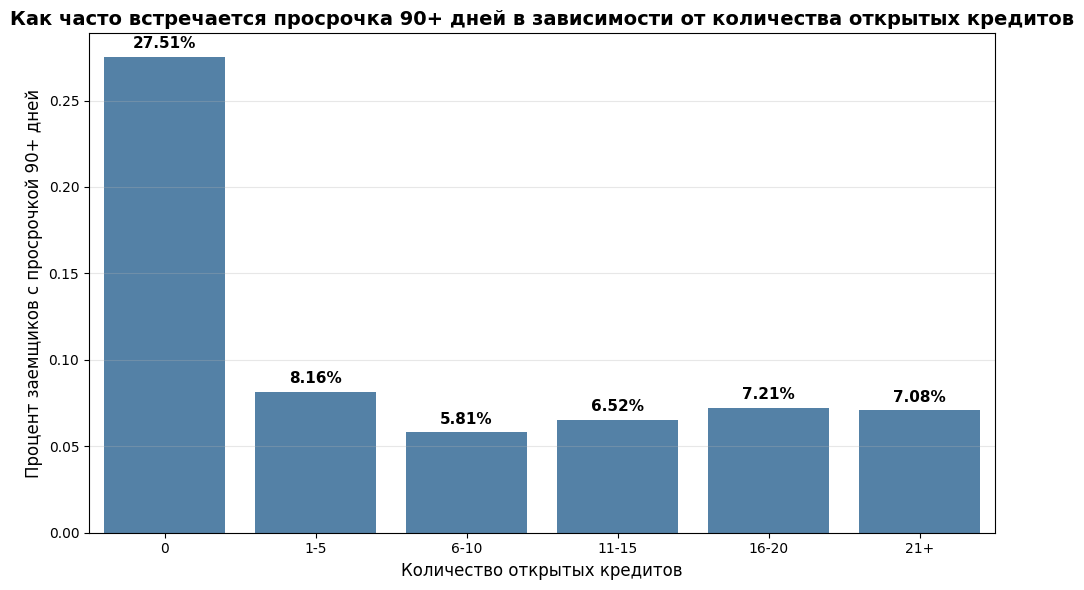

In [ ]:
train1['LoansGroup'] = pd.cut(train1['OpenLoans'],
                               bins=[-0.1, 0, 5, 10, 15, 20, 100],
                               labels=['0', '1-5', '6-10', '11-15', '16-20', '21+'])

loans_group_risk = train1.groupby('LoansGroup', observed=True)['Target'].mean().reset_index()

plt.figure(figsize=(10,6))
bars = sns.barplot(data=loans_group_risk, x='LoansGroup', y='Target', color='steelblue')
plt.title('Как часто встречается просрочка 90+ дней в зависимости от количества открытых кредитов', fontsize=14, fontweight='bold')
plt.xlabel('Количество открытых кредитов', fontsize=12)
plt.ylabel('Процент заемщиков с просрочкой 90+ дней', fontsize=12)

for i, bar in enumerate(bars.patches):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
              f'{loans_group_risk["Target"].iloc[i]:.2%}', ha='center', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

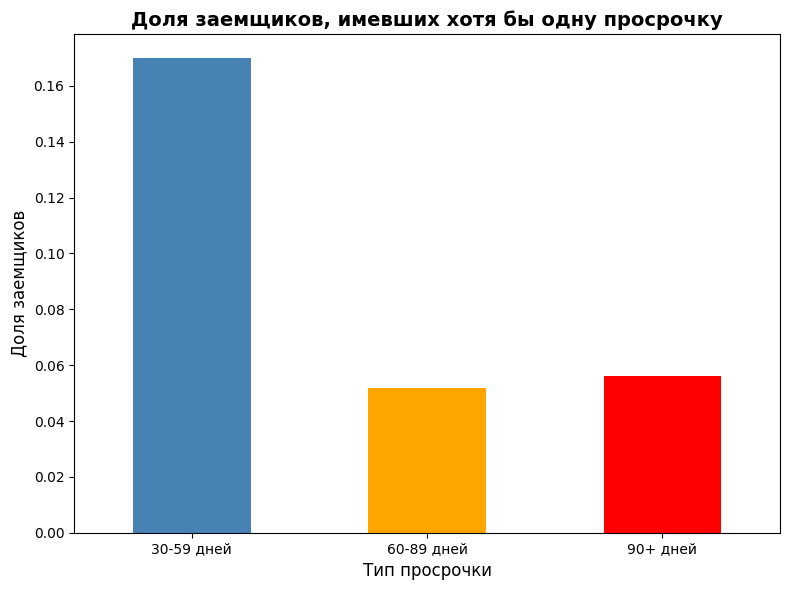

In [ ]:
# Сравнение трех типов просрочек
pastdue_cols = ['PastDueLess_60', 'PastDue60_90', 'PastDue90_More']
pastdue_compare = train1[pastdue_cols].apply(lambda x: x > 0).mean()

plt.figure(figsize=(8,6))
pastdue_compare.plot(kind='bar', color=['steelblue', 'orange', 'red'])
plt.title('Доля заемщиков, имевших хотя бы одну просрочку', fontsize=14, fontweight='bold')
plt.xlabel('Тип просрочки', fontsize=12)
plt.ylabel('Доля заемщиков', fontsize=12)
plt.xticks(ticks=[0,1,2], labels=['30-59 дней', '60-89 дней', '90+ дней'], rotation=0)

plt.tight_layout()
plt.show()

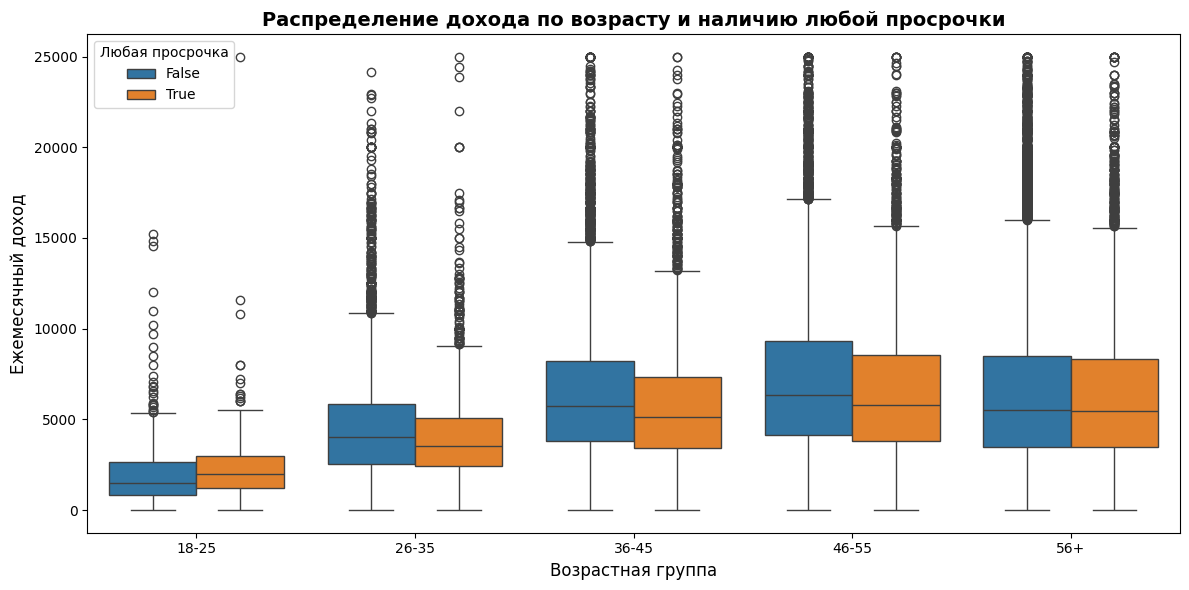

In [ ]:
# Создаем признак: была ли хотя бы одна просрочка
train1['AnyPastDue'] = (train1['PastDueLess_60'] > 0) | (train1['PastDue60_90'] > 0) | (train1['PastDue90_More'] > 0)

# Создаем возрастные группы
train1['AgeGroup'] = pd.cut(train1['Age'], bins=[0,25,35,45,55,100], labels=['18-25', '26-35', '36-45', '46-55', '56+'])

# Ограничиваем доход 99 перцентилем
income_limit = train1['MonthlyIncome'].quantile(0.99)
income_filtered = train1[train1['MonthlyIncome'] <= income_limit].copy()
income_filtered['AgeGroup'] = pd.cut(income_filtered['Age'], bins=[0,25,35,45,55,100], labels=['18-25', '26-35', '36-45', '46-55', '56+'])

plt.figure(figsize=(12,6))
sns.boxplot(data=income_filtered, x='AgeGroup', y='MonthlyIncome', hue='AnyPastDue')
plt.title('Распределение дохода по возрасту и наличию любой просрочки', fontsize=14, fontweight='bold')
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Ежемесячный доход', fontsize=12)
plt.legend(title='Любая просрочка')
plt.tight_layout()
plt.show()

Анализ показывает, что связь между доходом и наличием просрочек не является одинаковой для всех возрастов. В зависимости от возрастной группы характер этой связи меняется, что говорит о необходимости сегментированного подхода при оценке кредитного риска.

Молодежь (18-25): Нельзя полагаться только на доход. Нужно оценивать финансовую дисциплину, историю платежей и соотношение расходов к доходам.

Средний возраст (26-55): Доход является значимым фактором. Низкий доход = высокий риск.

Пожилые (56+): Доход почти не влияет на риск. Можно оценивать по другим критериям (кредитная история, наличие просрочек в прошлом).

Выбросы по доходу во всех группах нужно обрабатывать перед обучением моделей, чтобы они не искажали результаты.

/tmp/ipykernel_2631/1246303647.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Коэффициент', y='Признак', palette='RdBu_r')


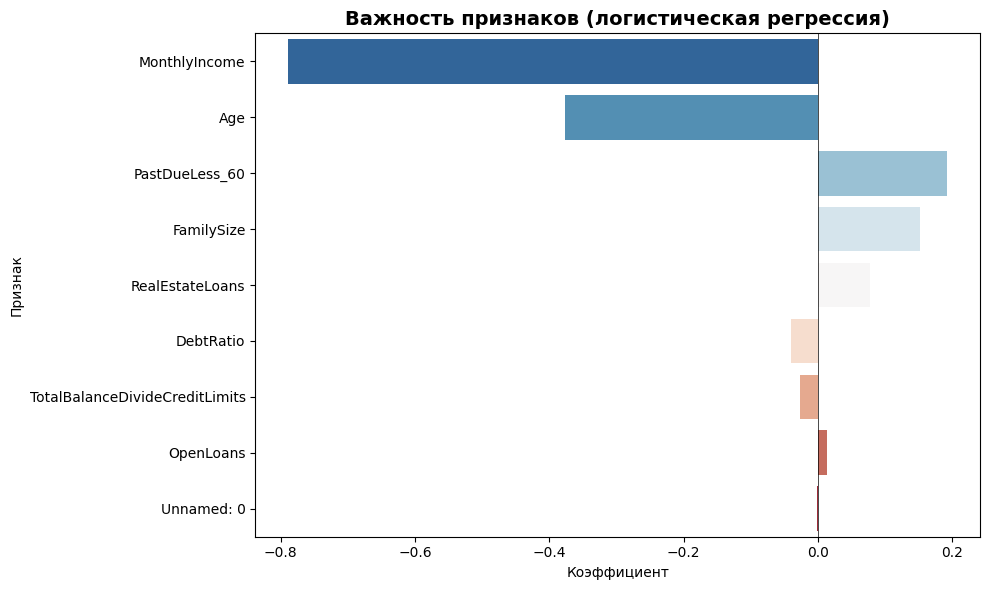

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = train1.drop(['Target', 'AgeGroup', 'AnyPastDue', 'LoansGroup', 'PastDue60_90', 'PastDue90_More'], axis=1)
y = train1['Target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_scaled, y)

importance = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': lr.coef_[0]
}).sort_values('Коэффициент', key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance, x='Коэффициент', y='Признак', palette='RdBu_r')
plt.title('Важность признаков (логистическая регрессия)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

Коэффициенты на графике показывают направление и силу влияния каждого признака на вероятность просрочки 90+ дней. Положительные значения (красные столбцы) увеличивают риск, отрицательные (синие) — снижают его. Чем дальше столбец от нуля, тем значимее признак. Так, высокий доход и возраст уменьшают риск, а наличие мелких просрочек и иждивенцев — увеличивают.


Коэффициенты показывают влияние при прочих равных (если все остальные признаки не меняются). Чем дальше столбец от нуля, тем важнее признак для предсказания. Знак (+ или -) показывает направление влияния


Три главных фактора, определяющих риск просрочки 90+ дней:

1. Доход (MonthlyIncome) — самый важный. Чем выше доход, тем ниже риск.

2. Возраст (Age) — второй по важности. Чем старше заемщик, тем он надежнее.

3. Мелкие просрочки в прошлом (PastDueLess_60) — третий фактор. Если человек часто опаздывал на 30-59 дней, велика вероятность, что дойдет и до 90+.

Дополнительные факторы:

Количество иждивенцев (FamilySize) умеренно увеличивает риск

Ипотеки (RealEstateLoans) слабо увеличивают риск

Остальные признаки (DebtRatio, TotalBalanceDivideCreditLimits, OpenLoans) почти не влияют на предсказание

Рекомендация банку:
При оценке кредитного риска в первую очередь обращать внимание на доход, возраст и историю мелких просрочек. Эти три фактора дают наибольшую предсказательную силу.

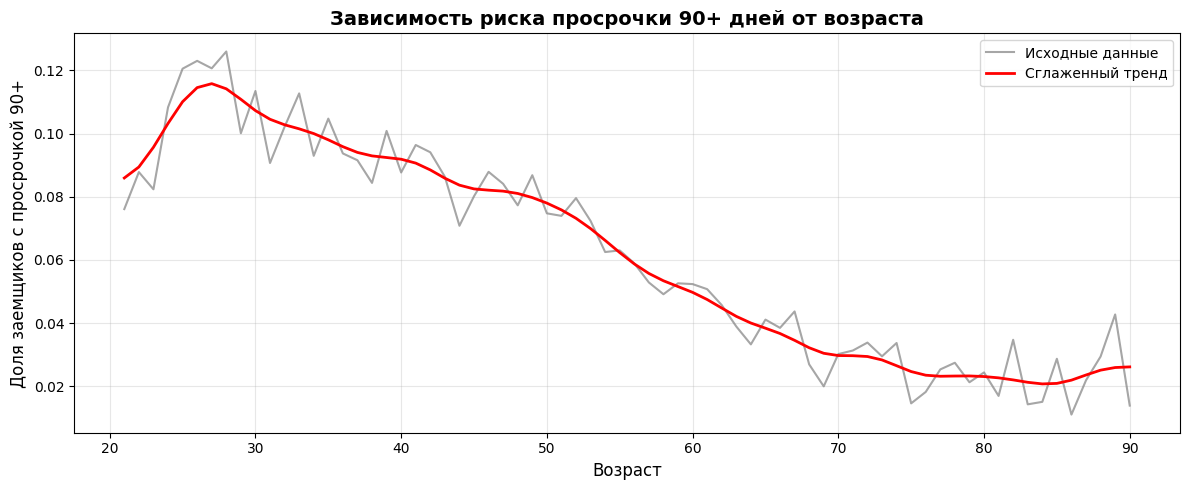

In [ ]:
from scipy.ndimage import gaussian_filter1d

# Ограничиваем возраст до 90 лет
age_filtered = train1[train1['Age'] <= 90]

# Сглаживаем риск по возрасту
age_risk = age_filtered.groupby('Age')['Target'].mean().reset_index()
smoothed = gaussian_filter1d(age_risk['Target'], sigma=2)

plt.figure(figsize=(12,5))
plt.plot(age_risk['Age'], age_risk['Target'], alpha=0.7, color='gray', label='Исходные данные')
plt.plot(age_risk['Age'], smoothed, color='red', linewidth=2, label='Сглаженный тренд')
plt.title('Зависимость риска просрочки 90+ дней от возраста', fontsize=14, fontweight='bold')
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Доля заемщиков с просрочкой 90+', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод по графику зависимости риска от возраста:**

Сглаженный тренд на графике показывает, что с увеличением возраста заемщика вероятность просрочки 90+ дней в целом снижается. Наибольший риск наблюдается в молодых возрастных группах (до 35 лет), после чего показатель постепенно уменьшается и достигает минимальных значений после 60 лет. Это подтверждает, что возраст является важным фактором кредитоспособности: молодые заемщики более склонны к финансовым трудностям, тогда как пожилые демонстрируют более ответственное отношение к выплатам по кредитам. Банку рекомендуется учитывать возрастную группу заемщика при принятии решения о выдаче кредита, проявляя повышенную осторожность при работе с клиентами младше 35 лет.

# 4 Вывод из анализа данных

Что мы выяснили из графиков:
1. Проблемы с данными (нужно обработать):
DebtRatio — есть мусор (значения в тысячи процентов, '03.май')

MonthlyIncome — выбросы до 3 млн (99% до 25000)

PastDue признаки — сильно коррелируют (мультиколлинеарность)

2. Важные признаки (оставляем):
PastDueLess_60 — главный фактор риска

MonthlyIncome — главный защитный фактор

Age — защитный фактор

FamilySize — увеличивает риск

RealEstateLoans — слабо увеличивает риск

3. Признаки, которые можно удалить:
PastDue60_90 и PastDue90_More — дублируют информацию (корреляция 0.98-0.99 с PastDueLess_60)

OpenLoans — почти не влияет (коэффициент 0.01)

TotalBalanceDivideCreditLimits — почти не влияет (-0.03)

4. Новые признаки (стоит добавить):
IncomeMissing — индикатор пропуска дохода (у нас уже нет пропусков, но в реальных данных был бы полезен)

AgeGroup — категории возраста (уже сделали для графиков)

TotalPastDue — сумма всех просрочек (для моделей)

DebtRatio_clean — очищенный DebtRatio (ограничить 200%)

In [ ]:
# Копируем данные
train_ml = train1.copy()

# 1. Создаем новый признак TotalPastDue
train_ml['TotalPastDue'] = train_ml['PastDueLess_60'] + train_ml['PastDue60_90'] + train_ml['PastDue90_More']

train_ml['MonthlyIncome_log'] = np.log1p(train_ml['MonthlyIncome'])

train_ml['Income_per_family'] = (
    train_ml['MonthlyIncome'] /
    (train_ml['FamilySize'] + 1)
)

train_ml['Debt_per_income'] = (
    train_ml['DebtRatio'] *
    train_ml['MonthlyIncome']
)

# 2. Очищаем DebtRatio (ограничиваем 200%)
train_ml['DebtRatio'] = train_ml['DebtRatio'].clip(upper=200)

train_ml['DebtRatio_log'] = np.log1p(train_ml['DebtRatio'])

# 3. Создаем AgeGroup (с нормальными границами, включая все возраста)
train_ml['AgeGroup'] = pd.cut(train_ml['Age'], bins=[17, 25, 35, 45, 55, 150], labels=['18-25', '26-35', '36-45', '46-55', '56+'])

# 4. Удаляем лишние признаки
drop_cols = ['PastDue60_90', 'PastDue90_More', 'OpenLoans', 'TotalBalanceDivideCreditLimits',
             'DebtRatio', 'AnyPastDue', 'LoansGroup']
train_ml = train_ml.drop(columns=drop_cols)

print("Признаки для модели:")
print(train_ml.columns.tolist())

Признаки для модели:
['Unnamed: 0', 'Age', 'FamilySize', 'PastDueLess_60', 'MonthlyIncome', 'RealEstateLoans', 'Target', 'AgeGroup', 'TotalPastDue', 'MonthlyIncome_log', 'Income_per_family', 'Debt_per_income', 'DebtRatio_log']


# 5 Разделение на обучающую и тестовую выборки

In [ ]:
from sklearn.model_selection import train_test_split

# Подготовка данных (признаки и целевая переменная)
X = train_ml.drop('Target', axis=1)
y = train_ml['Target']

# Кодируем категориальный признак AgeGroup
X = pd.get_dummies(X, columns=['AgeGroup'], drop_first=True)

# Разделяем на обучающую (80%) и валидационную (20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")
print(f"Распределение Target в train:\n{y_train.value_counts(normalize=True)}")
print(f"Распределение Target в val:\n{y_val.value_counts(normalize=True)}")

Размер обучающей выборки: (64183, 15)
Размер валидационной выборки: (16046, 15)
Распределение Target в train:
Target
0.0    0.930605
1.0    0.069395
Name: proportion, dtype: float64
Распределение Target в val:
Target
0.0    0.930575
1.0    0.069425
Name: proportion, dtype: float64


# 6 Поиск лучшей модели

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC  # Используем SVC вместо LinearSVC (есть predict_proba)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd
import time
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

KNN

In [ ]:
knn = KNeighborsClassifier()

results = []

knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(knn, knn_params, cv=cv, scoring='roc_auc')
knn_grid.fit(X_train, y_train)

knn_best = knn_grid.best_estimator_
knn_auc = roc_auc_score(y_val, knn_best.predict_proba(X_val)[:, 1])

results.append(["KNN", knn_grid.best_score_, knn_auc])

print("Лучшие параметры:", knn_grid.best_params_)
print("Лучший CV ROC-AUC:", knn_grid.best_score_)
print("Validation ROC-AUC:", knn_auc)

Лучшие параметры: {'n_neighbors': 9, 'weights': 'distance'}
Лучший CV ROC-AUC: 0.5456601423914194
Validation ROC-AUC: 0.546757268498101


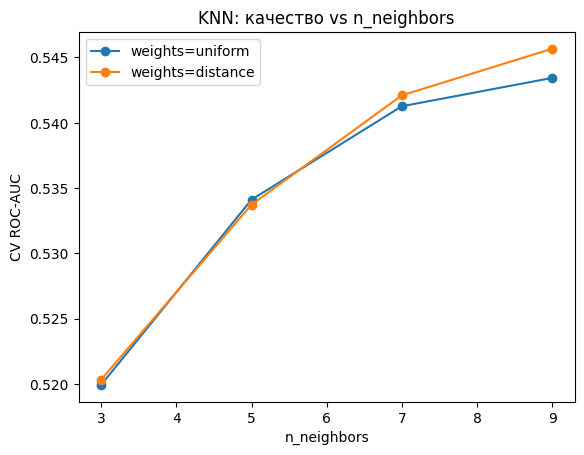

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(knn_grid.cv_results_)

plt.figure()

for w in df['param_weights'].unique():
    subset = df[df['param_weights'] == w]

    plt.plot(
        subset['param_n_neighbors'],
        subset['mean_test_score'],
        marker='o',
        label=f'weights={w}'
    )

plt.xlabel('n_neighbors')
plt.ylabel('CV ROC-AUC')
plt.title('KNN: качество vs n_neighbors')
plt.legend()
plt.show()

Небольшое количество соседей приводит к недообучению, большое количество - к переобучению. из графика можно сделать вывод, что weights - distance лучше

LOG REGRESSION

In [ ]:
from sklearn.pipeline import Pipeline

logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000))
])

log_params = {
    'model__C': [0.01, 0.1, 1, 10]
}

log_grid = GridSearchCV(
    logreg_pipe,
    log_params,
    cv=cv,
    scoring='roc_auc'
)

log_grid.fit(X_train, y_train)

log_best = log_grid.best_estimator_
log_auc = roc_auc_score(y_val, log_best.predict_proba(X_val)[:, 1])

results.append(["LogReg", log_grid.best_score_, log_auc])

print("Лучшие параметры:", log_grid.best_params_)
print("Лучший CV ROC-AUC:", log_grid.best_score_)
print("Validation ROC-AUC:", log_auc)

Лучшие параметры: {'model__C': 0.1}
Лучший CV ROC-AUC: 0.6728362409656449
Validation ROC-AUC: 0.6603857896070805


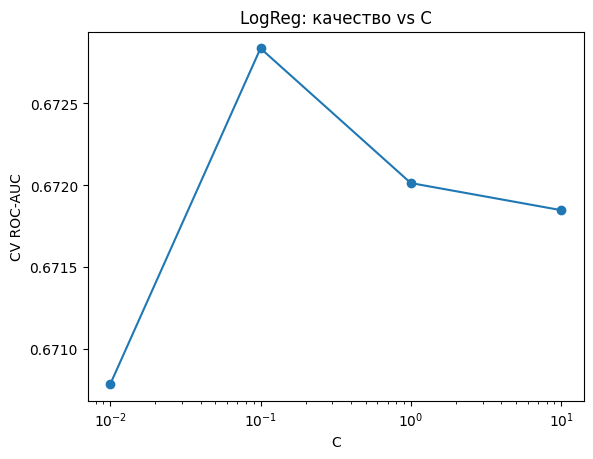

In [ ]:
df = pd.DataFrame(log_grid.cv_results_)

plt.figure()

plt.plot(
    df['param_model__C'],
    df['mean_test_score'],
    marker='o'
)

plt.xscale('log')
plt.xlabel('C')
plt.ylabel('CV ROC-AUC')
plt.title('LogReg: качество vs C')
plt.show()

При небольших значениях C модель слишком простая, что приводит к недообучению. при увеличении C качество улучшается и достигает максимума при C ≈ 0.1. далее увеличение C приводит к ухудшению качетсва  

SVC

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV

svc = LinearSVC(max_iter=3000)

calibrated_svc = CalibratedClassifierCV(
    estimator=svc,
    cv=3
)

svc_params = {
    'estimator__C': [0.1, 1, 10]
}

svc_grid = GridSearchCV(
    calibrated_svc,
    svc_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

svc_grid.fit(X_train, y_train)

svс_best = svc_grid.best_estimator_
svс_auc = roc_auc_score(y_val, svc_grid.predict_proba(X_val)[:, 1])

print("Лучшие параметры:", svc_grid.best_params_)
print("Лучший CV ROC-AUC:", svc_grid.best_score_)
print("Validation ROC-AUC:", svс_auc)

Лучшие параметры: {'estimator__C': 10}
Лучший CV ROC-AUC: 0.6511452616964634
Validation ROC-AUC: 0.6360488914196782


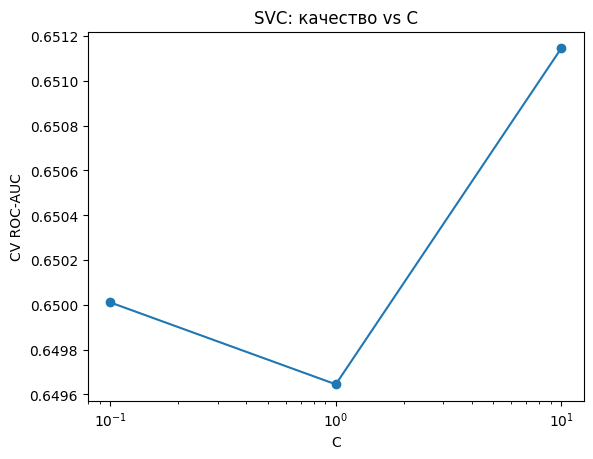

In [ ]:
df = pd.DataFrame(svc_grid.cv_results_)

plt.figure()

plt.plot(
    df['param_estimator__C'],
    df['mean_test_score'],
    marker='o'
)

plt.xscale('log')
plt.xlabel('C')
plt.ylabel('CV ROC-AUC')
plt.title('SVC: качество vs C')
plt.show()

Небольшое значение С приводит к недообучению, большое - к переобучению

SGD

In [ ]:
sgd_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SGDClassifier(loss='log_loss', max_iter=3000, random_state=42))
])

sgd_params = {
    'model__alpha': [1e-4, 1e-3, 1e-2],
    'model__penalty': ['l2', 'l1', 'elasticnet']
}

sgd_grid = GridSearchCV(
    sgd_pipe,
    sgd_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

sgd_grid.fit(X_train, y_train)

sgd_best = sgd_grid.best_estimator_
sgd_auc = roc_auc_score(
    y_val,
    sgd_best.predict_proba(X_val)[:, 1]
)

results.append(["SGD", sgd_grid.best_score_, sgd_auc])

print("Лучшие параметры:", sgd_grid.best_params_)
print("Лучший CV ROC-AUC:", sgd_grid.best_score_)
print("Validation ROC-AUC:", sgd_auc)

Лучшие параметры: {'model__alpha': 0.0001, 'model__penalty': 'l2'}
Лучший CV ROC-AUC: 0.7041391919176302
Validation ROC-AUC: 0.6719332307658272


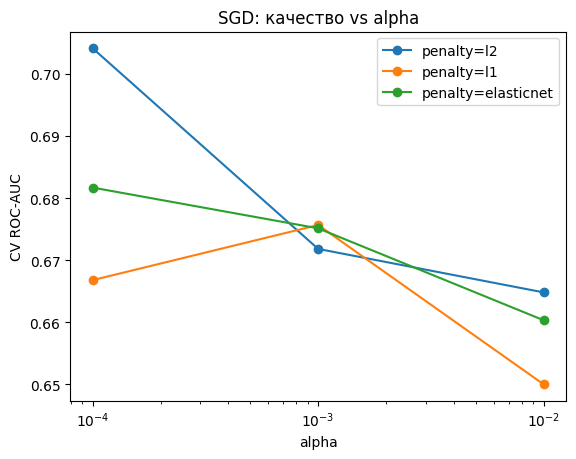

In [ ]:
import pandas as pd

sgd_grid.cv_results_
df = pd.DataFrame(sgd_grid.cv_results_)

import matplotlib.pyplot as plt

plt.figure()

for penalty in df['param_model__penalty'].unique():
    subset = df[df['param_model__penalty'] == penalty]

    plt.plot(
        subset['param_model__alpha'],
        subset['mean_test_score'],
        marker='o',
        label=f'penalty={penalty}'
    )

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV ROC-AUC')
plt.title('SGD: качество vs alpha')
plt.legend()
plt.show()

При небольших значениях альфа модель преобучается из-за слабой регуляризации, при болтших значениях становится слишком простой соответственно падает качество.

Регуляризация влияет на выбор весов: L1 может занулять веса и ухудшать качество модели, L2 - более стабильная, так как не обнуляет веса, а делает их очень маленькими

DECISION TREE

In [ ]:
tree = DecisionTreeClassifier()

tree_params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10]
}

DecisionTreeClassifier(
    class_weight='balanced'
)

tree_grid = GridSearchCV(tree, tree_params, cv=cv, scoring='roc_auc')
tree_grid.fit(X_train, y_train)

tree_best = tree_grid.best_estimator_
tree_auc = roc_auc_score(y_val, tree_best.predict_proba(X_val)[:, 1])

results.append(["Tree", tree_grid.best_score_, tree_auc])

print("Лучшие параметры:", tree_grid.best_params_)
print("Лучший CV ROC-AUC:", tree_grid.best_score_)
print("Validation ROC-AUC:", tree_auc)

Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Лучший CV ROC-AUC: 0.8128004042553093
Validation ROC-AUC: 0.803352937866503


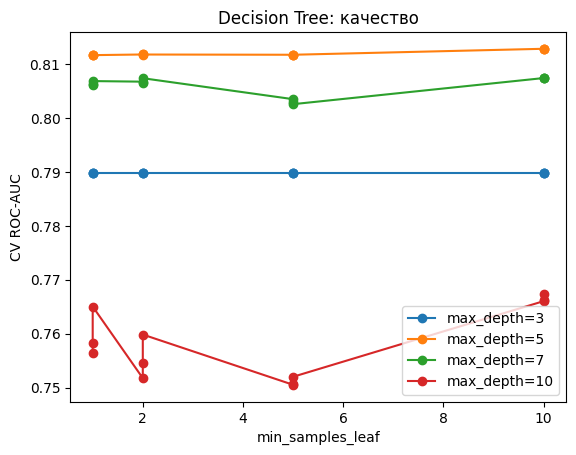

In [ ]:
df = pd.DataFrame(tree_grid.cv_results_)

plt.figure()

for depth in df['param_max_depth'].unique():
    subset = df[df['param_max_depth'] == depth]

    plt.plot(
        subset['param_min_samples_leaf'],
        subset['mean_test_score'],
        marker='o',
        label=f'max_depth={depth}'
    )

plt.xlabel('min_samples_leaf')
plt.ylabel('CV ROC-AUC')
plt.title('Decision Tree: качество')
plt.legend()
plt.show()

Оптимальным вариантом является глубина 3, так как при 10 заметно недообучение, а при 5 переобучение

RANDOM FOREST

In [ ]:
#ЛУЧШЕЕ 1
rf = RandomForestClassifier()

rf_params = {
    'n_estimators': [300, 400],
    'max_depth': [10, 15, None],
    'min_samples_leaf': [2, 5],
    'max_features': ['sqrt']
}


RandomForestClassifier(
    class_weight='balanced'
)

rf_grid = GridSearchCV(rf, rf_params, cv=cv, scoring='roc_auc')
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_auc = roc_auc_score(y_val, rf_best.predict_proba(X_val)[:, 1])

#results.append(["RF", rf_grid.best_score_, rf_auc])

print("Лучшие параметры:", rf_grid.best_params_)
print("Лучший CV ROC-AUC:", rf_grid.best_score_)
print("Validation ROC-AUC:", rf_auc)

Лучшие параметры: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 400}
Лучший CV ROC-AUC: 0.824986915221744
Validation ROC-AUC: 0.821704774390763


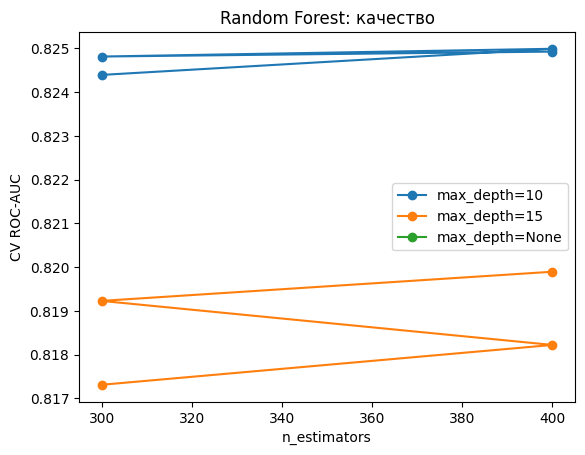

In [ ]:
df = pd.DataFrame(rf_grid.cv_results_)

plt.figure()

for depth in df['param_max_depth'].unique():
    subset = df[df['param_max_depth'] == depth]

    plt.plot(
        subset['param_n_estimators'],
        subset['mean_test_score'],
        marker='o',
        label=f'max_depth={depth}'
    )

plt.xlabel('n_estimators')
plt.ylabel('CV ROC-AUC')
plt.title('Random Forest: качество')
plt.legend()
plt.show()

Из графика делаем вывод, что чем больше деревеьев, тем стабильнее результат. так же при глубине дерева = 5 происходит недообучени, при глубине = 10 - переобучение. значит необходимо испольовать среднюю глубину

BOOSTING

In [ ]:
#ЛУЧШЕЕ 2
gb = GradientBoostingClassifier()

gb_params = {
    'n_estimators': [200, 300],
    'learning_rate': [0.03, 0.05],
    'max_depth': [3, 4],
    'subsample': [0.8],
    'min_samples_leaf': [1, 2, 5]
}

gb_grid = GridSearchCV(gb, gb_params, cv=cv, scoring='roc_auc')
gb_grid.fit(X_train, y_train)

gb_best = gb_grid.best_estimator_
gb_auc = roc_auc_score(y_val, gb_best.predict_proba(X_val)[:, 1])

#results.append(["GB", gb_grid.best_score_, gb_auc])

print("Лучшие параметры:", gb_grid.best_params_)
print("Лучший CV ROC-AUC:", gb_grid.best_score_)
print("Validation ROC-AUC:", gb_auc)

Лучшие параметры: {'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 300, 'subsample': 0.8}
Лучший CV ROC-AUC: 0.8267181680944987
Validation ROC-AUC: 0.8220522202145838


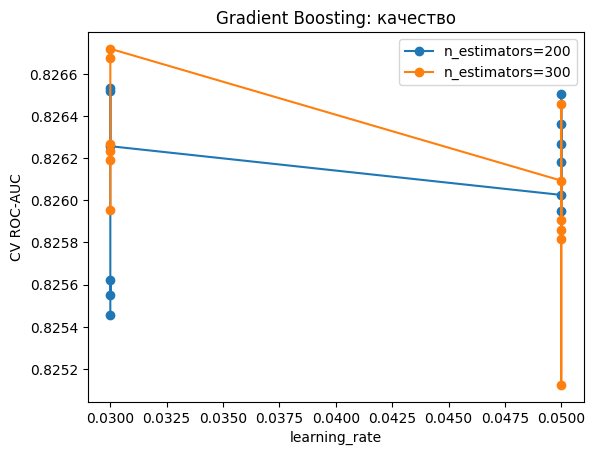

In [ ]:
df = pd.DataFrame(gb_grid.cv_results_)

plt.figure()

for n in df['param_n_estimators'].unique():
    subset = df[df['param_n_estimators'] == n]

    plt.plot(
        subset['param_learning_rate'],
        subset['mean_test_score'],
        marker='o',
        label=f'n_estimators={n}'
    )

plt.xlabel('learning_rate')
plt.ylabel('CV ROC-AUC')
plt.title('Gradient Boosting: качество')
plt.legend()
plt.show()

Из графика делаем вывод, что при небольшом шаге обучения качечтво лучше, но необходимо использовать больше деревьев, при большом шаге - обучение быстрее, но хуже обобщение

# 7. 2 лучшие модели

На основе сравнительной таблицы метрик в предыдущем разделе, для
предсказания были выбраны две модели, показавшие наивысший ROC-AUC на валидации: Boosting и Random Forest.

In [ ]:
test

,Age,FamilySize,PastDueLess_60,PastDue60_90,PastDue90_More,DebtRatio,MonthlyIncome,TotalBalanceDivideCreditLimits,OpenLoans,RealEstateLoans
0,52,2.0,0,0,0,0.267947,9583.0,0.001019,14,2
1,40,2.0,0,0,0,0.411935,9333.0,0.163523,10,2
2,33,3.0,1,1,0,0.620985,1400.0,1.011239,8,0
3,41,3.0,0,0,0,0.567520,9100.0,0.476197,10,3
4,55,2.0,0,0,0,0.079566,12982.0,0.247196,9,0
...,...,...,...,...,...,...,...,...,...,...
19993,58,0.0,0,0,0,93.000000,5400.0,0.165388,1,0
19994,50,3.0,0,0,0,3191.000000,5400.0,0.006685,11,2
19995,55,1.0,1,0,0,0.225254,7000.0,0.482834,3,1
19996,54,2.0,0,0,0,0.311982,11333.0,0.081970,19,1


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score


X = train_ml.drop('Target', axis=1)
y = train_ml['Target']
X = pd.get_dummies(X, columns=['AgeGroup'], drop_first=True)

# Подготовка test
test_ml = test.copy()
test_ml['TotalPastDue'] = test_ml['PastDueLess_60'] + test_ml['PastDue60_90'] + test_ml['PastDue90_More']
test_ml['DebtRatio'] = test_ml['DebtRatio'].clip(upper=200)
test_ml['AgeGroup'] = pd.cut(test_ml['Age'], bins=[17,25,35,45,55,150],
                              labels=['18-25','26-35','36-45','46-55','56+'])

drop_cols = ['PastDue60_90', 'PastDue90_More', 'OpenLoans',
             'TotalBalanceDivideCreditLimits', 'DebtRatio', 'AnyPastDue', 'LoansGroup']
test_ml = test_ml.drop(columns=[c for c in drop_cols if c in test_ml.columns])
X_test = pd.get_dummies(test_ml, columns=['AgeGroup'], drop_first=True)

# Выравниваем колонки
for col in X.columns:
    if col not in X_test.columns:
        X_test[col] = 0
X_test = X_test[X.columns]

print(f"Train: {X.shape}, Test: {X_test.shape}")

print("\nОбучаем Random Forest...")
rf_best = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_best.fit(X, y)

rf_val_class = rf_best.predict(X_val)
rf_acc = accuracy_score(y_val, rf_val_class)
print("Random Forest Accuracy:", rf_acc)

print("Обучаем Gradient Boosting...")
gb_best = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_best.fit(X, y)


gb_val_class = gb_best.predict(X_val)
gb_acc = accuracy_score(y_val, gb_val_class)
print("Gradient Boosting Accuracy:", gb_acc)

rf_val_prob = rf_best.predict_proba(X_val)[:, 1]
gb_val_prob = gb_best.predict_proba(X_val)[:, 1]

rf_pred = rf_best.predict_proba(X_test)[:, 1]
gb_pred = gb_best.predict_proba(X_test)[:, 1]
ensemble_pred = (rf_pred + gb_pred) / 2

ensemble_val_prob = (rf_val_prob + gb_val_prob) / 2
ensemble_val_class = (ensemble_val_prob > 0.5).astype(int)
ensemble_acc = accuracy_score(y_val, ensemble_val_class)

print("Ensemble Accuracy:", ensemble_acc)

# Сохранение
test_ids = np.arange(100001, 100001 + len(test))

submission_rf = pd.DataFrame({'ID': test_ids, 'Target': rf_pred})
submission_gb = pd.DataFrame({'ID': test_ids, 'Target': gb_pred})
submission_ensemble = pd.DataFrame({'ID': test_ids, 'Target': ensemble_pred})

submission_rf.to_csv('submission_random_forest.csv', index=False)
submission_gb.to_csv('submission_gradient_boosting.csv', index=False)
submission_ensemble.to_csv('submission_ensemble.csv', index=False)

print("\nФайлы сохранены!")
print(submission_ensemble.head())

Train: (80229, 15), Test: (19998, 15)

Обучаем Random Forest...
Random Forest Accuracy: 0.9407952137604387
Обучаем Gradient Boosting...
Gradient Boosting Accuracy: 0.9338776018945532
Ensemble Accuracy: 0.9372429265860651

Файлы сохранены!
       ID    Target
0  100001  0.067794
1  100002  0.094184
2  100003  0.401567
3  100004  0.109012
4  100005  0.106472


**Вывод:** Усреднение двух моделей дало точность 0.9372, что делает предсказание более надёжным.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

X = train_ml.drop('Target', axis=1)
y = train_ml['Target']
X = pd.get_dummies(X, columns=['AgeGroup'], drop_first=True)

# Подготовка test
test_ml = test.copy()
test_ml['TotalPastDue'] = test_ml['PastDueLess_60'] + test_ml['PastDue60_90'] + test_ml['PastDue90_More']
test_ml['DebtRatio'] = test_ml['DebtRatio'].clip(upper=200)
test_ml['AgeGroup'] = pd.cut(test_ml['Age'], bins=[17,25,35,45,55,150],
                              labels=['18-25','26-35','36-45','46-55','56+'])

drop_cols = ['PastDue60_90', 'PastDue90_More', 'OpenLoans',
             'TotalBalanceDivideCreditLimits', 'DebtRatio', 'AnyPastDue', 'LoansGroup']
test_ml = test_ml.drop(columns=[c for c in drop_cols if c in test_ml.columns])
X_test = pd.get_dummies(test_ml, columns=['AgeGroup'], drop_first=True)

# Выравниваем колонки
for col in X.columns:
    if col not in X_test.columns:
        X_test[col] = 0
X_test = X_test[X.columns]

print(f"Train: {X.shape}, Test: {X_test.shape}")

# Random Forest
print("\nОбучаем Random Forest...")
rf_best = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_best.fit(X, y)

rf_val_prob = rf_best.predict_proba(X_val)[:, 1]
rf_auc = roc_auc_score(y_val, rf_val_prob)
rf_val_class = rf_best.predict(X_val)
rf_acc = accuracy_score(y_val, rf_val_class)

print(f"Random Forest - AUC: {rf_auc:.4f}, Accuracy: {rf_acc:.4f}")

# Gradient Boosting
print("\nОбучаем Gradient Boosting...")
gb_best = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_best.fit(X, y)

gb_val_prob = gb_best.predict_proba(X_val)[:, 1]
gb_auc = roc_auc_score(y_val, gb_val_prob)
gb_val_class = gb_best.predict(X_val)
gb_acc = accuracy_score(y_val, gb_val_class)

print(f"Gradient Boosting - AUC: {gb_auc:.4f}, Accuracy: {gb_acc:.4f}")

# Ensemble
ensemble_val_prob = (rf_val_prob + gb_val_prob) / 2
ensemble_auc = roc_auc_score(y_val, ensemble_val_prob)
ensemble_val_class = (ensemble_val_prob > 0.5).astype(int)
ensemble_acc = accuracy_score(y_val, ensemble_val_class)

print(f"\nEnsemble - AUC: {ensemble_auc:.4f}, Accuracy: {ensemble_acc:.4f}")

# Предсказания для test
rf_pred = rf_best.predict_proba(X_test)[:, 1]
gb_pred = gb_best.predict_proba(X_test)[:, 1]
ensemble_pred = (rf_pred + gb_pred) / 2

# Сохранение
test_ids = np.arange(100001, 100001 + len(test))

submission_rf = pd.DataFrame({'ID': test_ids, 'Target': rf_pred})
submission_gb = pd.DataFrame({'ID': test_ids, 'Target': gb_pred})
submission_ensemble = pd.DataFrame({'ID': test_ids, 'Target': ensemble_pred})

submission_rf.to_csv('submission_random_forest.csv', index=False)
submission_gb.to_csv('submission_gradient_boosting.csv', index=False)
submission_ensemble.to_csv('submission_ensemble.csv', index=False)

print("\nФайлы сохранены!")
print(submission_ensemble.head())

Train: (80229, 15), Test: (19998, 15)

Обучаем Random Forest...
Random Forest - AUC: 0.8827, Accuracy: 0.9408

Обучаем Gradient Boosting...
Gradient Boosting - AUC: 0.8312, Accuracy: 0.9339

Ensemble - AUC: 0.8654, Accuracy: 0.9372

Файлы сохранены!
       ID    Target
0  100001  0.067794
1  100002  0.094184
2  100003  0.401567
3  100004  0.109012
4  100005  0.106472
